# Fraud Detection on Credit Card Applications with a Self-Organizing Map (SOM)

## Objective
Detect **potential fraud** in credit card applications using an **unsupervised** Self-Organizing Map (SOM) implemented **from scratch** (no MiniSom).

The idea (as in the classic unsupervised fraud-detection workflow):
1. Train a SOM on the customer features (without using the `Class` label).
2. Compute a **distance map (U-Matrix)** to reveal outliers — customers that do **not** fit any cluster are the suspicious ones.
3. For each customer, measure how far it is from its winning neuron (outlier score).
4. Rank customers by that score to extract the most likely fraud candidates.
5. Finally, **join with the `Class` label** to specify whether each flagged card was **approved (1)** or **not approved (0)**.

**Dataset:** `Credit_Card_Applications.csv`
- `CustomerID` — customer identifier
- `A1` … `A14` — anonymized application features
- `Class` — 1 = application **approved**, 0 = application **not approved**

## 1. Import Required Libraries

We use only `NumPy`, `Pandas` and `Matplotlib` — plus `MinMaxScaler` from scikit-learn for feature scaling. The SOM itself is implemented from scratch.

In [37]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Make plots a bit larger and reproducible
plt.rcParams["figure.figsize"] = (10, 8)
np.random.seed(42)

## 2. Load and Explore the Dataset

We load the CSV, inspect its shape, columns and first rows, then look at the distribution of the target `Class` (1 = approved, 0 = not approved).

In [38]:
# Load the dataset (works whether the notebook runs from the workspace root or from seance1/)
import os

csv_path = "Credit_Card_Applications.csv"
if not os.path.exists(csv_path):
    csv_path = os.path.join("..", "Credit_Card_Applications.csv")

dataset = pd.read_csv(csv_path)

print("Loaded:", os.path.abspath(csv_path))
print("Shape:", dataset.shape)
print("\nColumns:", list(dataset.columns))
dataset.head()

Loaded: c:\Users\lenovo\Desktop\deep-learning-and-transformers\seance1\Credit_Card_Applications.csv
Shape: (690, 16)

Columns: ['CustomerID', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'Class']


,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
0,15776156,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,15739548,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,15662854,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,15687688,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,15715750,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


In [39]:
# Summary statistics and target distribution
print(dataset.describe().T)

print("\nClass distribution (1 = approved, 0 = not approved):")
print(dataset["Class"].value_counts())
print("\nApproval rate: {:.2%}".format(dataset["Class"].mean()))

            count          mean           std          min           25%  \
CustomerID  690.0  1.569047e+07  71506.473912  15565714.00  1.563169e+07   
A1          690.0  6.782609e-01      0.467482         0.00  0.000000e+00   
A2          690.0  3.156820e+01     11.853273        13.75  2.267000e+01   
A3          690.0  4.758725e+00      4.978163         0.00  1.000000e+00   
A4          690.0  1.766667e+00      0.430063         1.00  2.000000e+00   
A5          690.0  7.372464e+00      3.683265         1.00  4.000000e+00   
A6          690.0  4.692754e+00      1.992316         1.00  4.000000e+00   
A7          690.0  2.223406e+00      3.346513         0.00  1.650000e-01   
A8          690.0  5.231884e-01      0.499824         0.00  0.000000e+00   
A9          690.0  4.275362e-01      0.495080         0.00  0.000000e+00   
A10         690.0  2.400000e+00      4.862940         0.00  0.000000e+00   
A11         690.0  4.579710e-01      0.498592         0.00  0.000000e+00   
A12         

## 3. Prepare the Features for Training

- `X` = all features (`A1` … `A14`), excluding `CustomerID` and the target `Class`.
- `y` = the `Class` column (kept aside — the SOM is **unsupervised**, so it never sees `y` during training).
- `CustomerID` is kept separately so we can report which customers are suspicious.

We scale `X` to `[0, 1]` with `MinMaxScaler`, which is required for stable SOM training.

In [40]:
# Separate features, target and customer IDs
customer_ids = dataset["CustomerID"].values
y = dataset["Class"].values                      # 1 = approved, 0 = not approved
X = dataset.drop(columns=["CustomerID", "Class"]).values.astype(float)

print("X shape:", X.shape)
print("y shape:", y.shape)

# Scale features to [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X)

print("\nMin per feature after scaling:", X_scaled.min(axis=0))
print("Max per feature after scaling:", X_scaled.max(axis=0))

X shape: (690, 14)
y shape: (690,)

Min per feature after scaling: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Max per feature after scaling: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 4. Implement the Self-Organizing Map (SOM) from Scratch

The SOM algorithm is implemented **from scratch** in the module `som/som.py`
(NumPy only, no MiniSom). We simply import it here.

The SOM is a 2D grid of neurons, each holding a weight vector with the same dimension as the input.

Training loop (Kohonen algorithm):
1. **Initialize** the weights (randomly, or with PCA-like linear initialization).
2. For each sample, find the **BMU** (Best Matching Unit) = neuron with the smallest Euclidean distance.
3. Compute the **learning rate** `α(t)` and the **neighborhood radius** `σ(t)`, both decaying exponentially over time.
4. **Update** the BMU and its neighbors: `w += α(t) · h(d) · (x − w)`, where `h(d) = exp(−d² / (2σ²))` is a Gaussian neighborhood function.
5. Repeat for many iterations.

The module also provides `distance_map()` (the **U-Matrix**), `winner_distance()` (outlier score), `win_map()` and `quantization_error()`.

In [41]:
# Import the from-scratch SOM from the local `som` package (som/som.py)
# We make sure the notebook directory is importable, then import the class.
import sys
import os

sys.path.insert(0, os.path.abspath("."))

from som import SOM

print("SOM imported from:", os.path.abspath(os.path.join("som", "som.py")))
print("SOM class:", SOM)

SOM imported from: c:\Users\lenovo\Desktop\deep-learning-and-transformers\seance1\som\som.py
SOM class: <class 'som.som.SOM'>


## 5. Train the SOM on the Dataset

We instantiate a `10 x 10` map and train it on the scaled features. The learning rate and neighborhood radius decay over the iterations so the map first organizes globally, then refines locally.

In [42]:
# Instantiate and train the SOM
som = SOM(grid=(10, 10), input_dim=X_scaled.shape[1],
          learning_rate=0.5, n_iter=1000, seed=42)

som.train(X_scaled, verbose=True)

Iteration 100/1000  alpha=0.4529  radius=4.2636
Iteration 200/1000  alpha=0.4098  radius=3.6297
Iteration 300/1000  alpha=0.3708  radius=3.0901
Iteration 400/1000  alpha=0.3355  radius=2.6308
Iteration 500/1000  alpha=0.3036  radius=2.2397
Iteration 600/1000  alpha=0.2747  radius=1.9067
Iteration 700/1000  alpha=0.2485  radius=1.6233
Iteration 800/1000  alpha=0.2249  radius=1.3820
Iteration 900/1000  alpha=0.2035  radius=1.1765
Iteration 1000/1000  alpha=0.1841  radius=1.0016
Training complete.


## 6. Visualize the Distance Map (U-Matrix)

The **U-Matrix** shows, for each neuron, the average distance to its neighbors.
- **Dark / low values** → neurons are similar → they belong to the same cluster.
- **Light / high values** → strong differences between neighboring neurons → cluster boundaries or isolated regions.

Isolated high-distance regions often correspond to **outliers**, which is exactly what we want to catch for fraud detection.

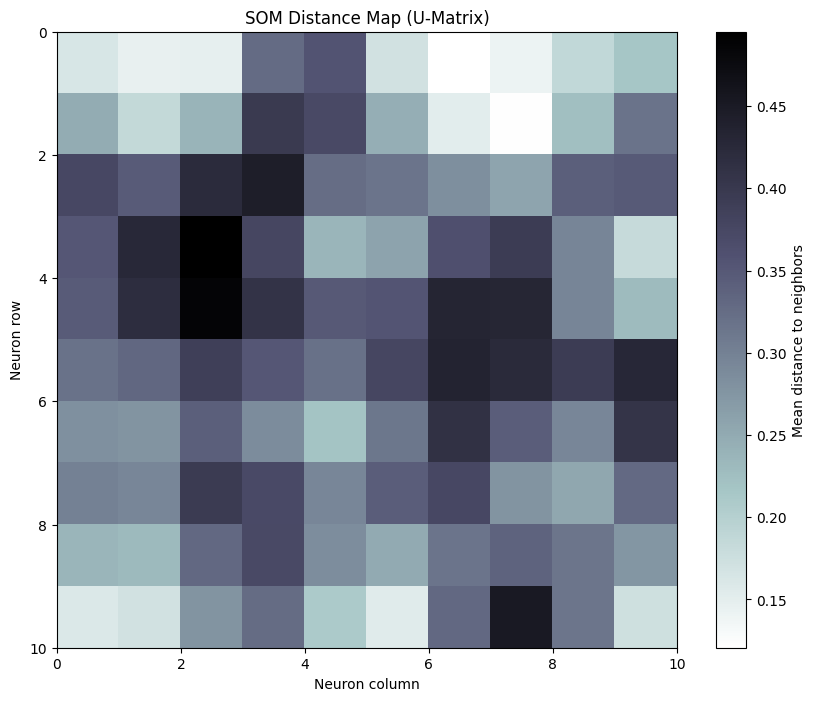

In [43]:
# Compute and plot the U-Matrix (distance map)
umatrix = som.distance_map()

plt.figure(figsize=(10, 8))
plt.pcolor(umatrix, cmap="bone_r")   # light = high distance = boundary/outlier
plt.colorbar(label="Mean distance to neighbors")
plt.title("SOM Distance Map (U-Matrix)")
plt.xlabel("Neuron column")
plt.ylabel("Neuron row")
plt.gca().invert_yaxis()
plt.show()

## 7. Identify Fraud Candidates from the SOM

For each customer we compute the distance to its winning neuron (BMU). A **large distance means the customer is poorly represented** by the map — a likely outlier / anomaly.

We store this score per `CustomerID`, then flag customers whose score is above a threshold as **potential fraud candidates**. Here we use the **mean + 1 standard deviation** of the scores as the threshold (a common, simple rule).

In [44]:
# Outlier score for every customer = distance to its BMU
scores = som.winner_distance(X_scaled)

# Store scores in a DataFrame with CustomerID
score_df = pd.DataFrame({"CustomerID": customer_ids, "distance": scores})

# Threshold: mean + 1 standard deviation
threshold = scores.mean() + scores.std()
score_df["fraud_candidate"] = score_df["distance"] > threshold

print(f"Threshold (mean + 1*std): {threshold:.4f}")
print(f"Number of fraud candidates: {score_df['fraud_candidate'].sum()} "
      f"out of {len(score_df)}")
score_df.head()

Threshold (mean + 1*std): 0.7130
Number of fraud candidates: 108 out of 690


,CustomerID,distance,fraud_candidate
0,15776156,0.422548,False
1,15739548,0.339402,False
2,15662854,0.591291,False
3,15687688,0.600984,False
4,15715750,0.401736,False


## 8. Mark the Approved Applications on the Map

Now we overlay the customers on the U-Matrix using their BMU coordinates:
- **Circles (`o`)** = approved applications (`Class = 1`)
- **Crosses (`x`)** = not approved applications (`Class = 0`)
- **White circles** highlight the flagged fraud candidates.

This lets us visually link each customer's position and approval status to the cluster boundaries.

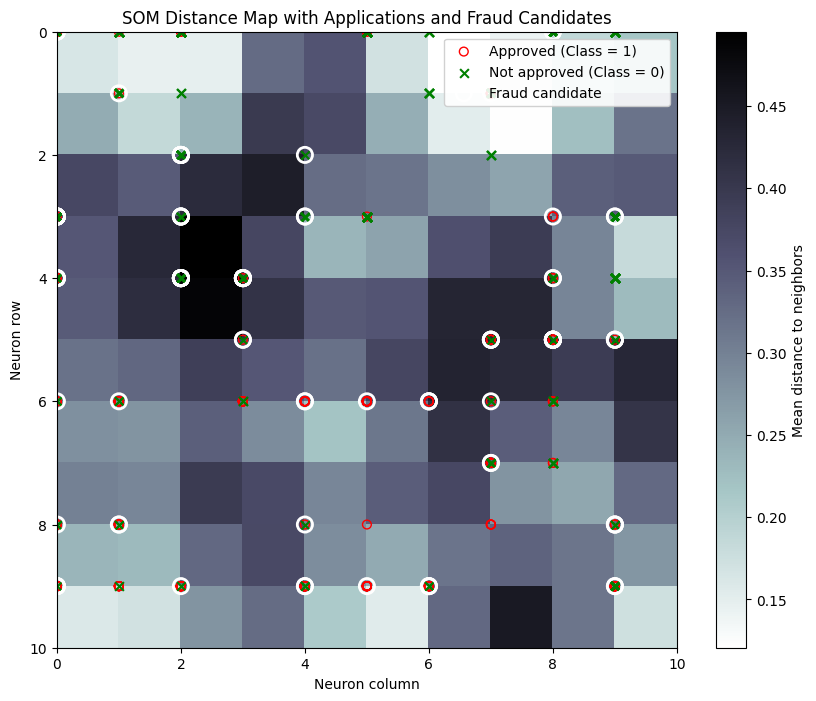

In [45]:
# Compute the BMU coordinates for every customer
bmu_coords = np.array([som.find_bmu(x) for x in X_scaled])

approved = y == 1        # Class == 1
not_approved = y == 0    # Class == 0
candidates = score_df["fraud_candidate"].values

plt.figure(figsize=(10, 8))
plt.pcolor(umatrix, cmap="bone_r")
plt.colorbar(label="Mean distance to neighbors")

# Approved applications (circles)
plt.scatter(bmu_coords[approved, 1], bmu_coords[approved, 0],
            marker="o", s=40, facecolors="none", edgecolors="red",
            label="Approved (Class = 1)")

# Not approved applications (crosses)
plt.scatter(bmu_coords[not_approved, 1], bmu_coords[not_approved, 0],
            marker="x", s=40, color="green",
            label="Not approved (Class = 0)")

# Flagged fraud candidates (white circles)
plt.scatter(bmu_coords[candidates, 1], bmu_coords[candidates, 0],
            marker="o", s=120, facecolors="none", edgecolors="white",
            linewidths=2, label="Fraud candidate")

plt.title("SOM Distance Map with Applications and Fraud Candidates")
plt.xlabel("Neuron column")
plt.ylabel("Neuron row")
plt.gca().invert_yaxis()
plt.legend(loc="upper right", framealpha=0.9)
plt.show()

## 9. Rank and Extract the Most Likely Fraudulent Customers

We sort customers by their outlier score (descending) and take the top candidates. Each candidate is joined with the `Class` label so we can **specify whether the card was approved or not**.

A customer with a high outlier score who was nonetheless **approved** is the most suspicious case — the SOM says their profile does not fit any normal group, yet the application went through.

In [46]:
# Attach the approval status (Class) to the score table
score_df["approved"] = y
score_df["status"] = np.where(score_df["approved"] == 1, "Approved", "Not approved")

# Rank by outlier score (descending) and keep the fraud candidates
ranked = score_df.sort_values("distance", ascending=False).reset_index(drop=True)
top_fraud = ranked[ranked["fraud_candidate"]].copy()

print(f"Top {len(top_fraud)} most likely fraudulent customers:\n")
print(top_fraud[["CustomerID", "distance", "approved", "status"]]
      .to_string(index=False))

# How many of the flagged candidates were actually approved?
n_approved = (top_fraud["approved"] == 1).sum()
n_not = (top_fraud["approved"] == 0).sum()
print(f"\nAmong the flagged candidates: {n_approved} approved, {n_not} not approved.")

Top 108 most likely fraudulent customers:

 CustomerID  distance  approved       status
   15790113  1.583387         1     Approved
   15799785  1.354877         1     Approved
   15605872  1.154317         0 Not approved
   15728010  1.145111         1     Approved
   15767264  1.141600         0 Not approved
   15645820  1.097039         1     Approved
   15750104  1.096435         0 Not approved
   15692137  1.059158         0 Not approved
   15781574  1.014189         0 Not approved
   15621423  1.013605         1     Approved
   15689268  1.010874         1     Approved
   15813192  0.991365         0 Not approved
   15792107  0.981078         0 Not approved
   15699963  0.980854         1     Approved
   15723827  0.976533         1     Approved
   15772329  0.969968         1     Approved
   15593694  0.969398         1     Approved
   15705379  0.966256         0 Not approved
   15793825  0.942421         0 Not approved
   15696361  0.941931         0 Not approved
   15651460 

## Conclusion

- We trained a **Self-Organizing Map from scratch** (no MiniSom) on the scaled application features, **without using the `Class` label**.
- The **U-Matrix** revealed the cluster structure and boundary regions.
- Using the **distance to the winning neuron** as an outlier score, we flagged a small set of **potential fraud candidates**.
- Joining the candidates with `Class` tells us **whether each flagged card was approved (1) or not approved (0)** — the approved-but-outlier cases are the most suspicious.

**Next steps (optional):** this unsupervised step is typically followed by a supervised classifier (e.g., an ANN) trained on the SOM-derived features to predict the probability of fraud.